In [12]:
# Text as Data Final Project
# Author: Sejal Jagtap

import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import spacy

# load spacy model
nlp = spacy.load("en_core_web_sm")
stopwords = nlp.Defaults.stop_words

In [21]:
texts = {}
folder_path = "texts"

for filename in os.listdir(folder_path):
    if filename.endswith(".txt"):
        with open(os.path.join(folder_path, filename), "r", encoding="utf-8") as f:
            texts[filename] = f.read()

print(f"Loaded {len(texts)} documents")

Loaded 23 documents


In [22]:
def split_sentences(text):
    return re.split(r"(?<=[.!?])\s+", text)


trade_windows = []
metadata = []

for doc_name, text in texts.items():
    sentences = split_sentences(text)

    for i, sent in enumerate(sentences):
        if re.search(r"\btrade\w*\b", sent.lower()):

            start = max(0, i - 2)
            end = min(len(sentences), i + 3)

            window = " ".join(sentences[start:end])

            trade_windows.append(window)
            metadata.append(doc_name)

print(f"Extracted {len(trade_windows)} windows")

Extracted 2841 windows


In [23]:
df_windows = pd.DataFrame({"document": metadata, "text": trade_windows})

df_windows.head()

,document,text
0,A32837.txt,it may be 10000 l. and so i● often falls out: ...
1,A32837.txt,and Plantations sell not at above seven years'...
2,A32837.txt,New England incomparably is the worst Land of ...
3,A32837.txt,Very angry doubtless he will be; but what then...
4,A32837.txt,"for his Money, rather than buy Lands at Eighte..."


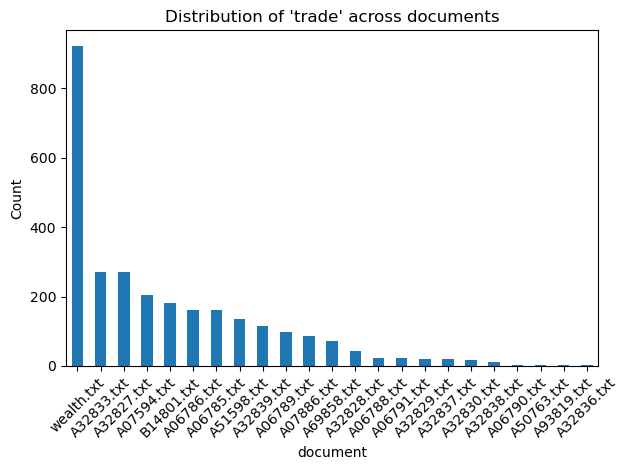

In [24]:
doc_counts = df_windows.groupby("document").size().sort_values(ascending=False)

plt.figure()
doc_counts.plot(kind="bar")
plt.title("Distribution of 'trade' across documents")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
words = []

for text in trade_windows:
    tokens = re.findall(r"\b\w+\b", text.lower())
    words.extend([w for w in tokens if w not in stopwords and len(w) > 2])

common_words = Counter(words).most_common(25)
common_words

[('trade', 7544),
 ('great', 2517),
 ('money', 1975),
 ('commodities', 1575),
 ('foreign', 1418),
 ('merchants', 1355),
 ('country', 1194),
 ('england', 1150),
 ('hath', 1016),
 ('countries', 973),
 ('interest', 936),
 ('men', 922),
 ('time', 897),
 ('company', 884),
 ('said', 877),
 ('good', 874),
 ('trades', 857),
 ('shall', 814),
 ('kingdom', 811),
 ('east', 792),
 ('stock', 789),
 ('exchange', 774),
 ('people', 768),
 ('greater', 735),
 ('merchant', 734)]

In [26]:
context_words = []

for text in trade_windows:
    tokens = re.findall(r"\b\w+\b", text.lower())

    for i, word in enumerate(tokens):
        if "trade" in word:
            window = tokens[max(0, i - 5) : i + 6]
            context_words.extend([w for w in window if w not in stopwords])

Counter(context_words).most_common(25)

[('trade', 7951),
 ('trades', 898),
 ('foreign', 642),
 ('great', 489),
 ('east', 329),
 ('india', 274),
 ('increase', 271),
 ('england', 256),
 ('decay', 243),
 ('merchants', 240),
 ('particular', 214),
 ('carrying', 214),
 ('traders', 210),
 ('money', 204),
 ('general', 204),
 ('balance', 188),
 ('free', 188),
 ('consumption', 187),
 ('employed', 181),
 ('stock', 158),
 ('colony', 154),
 ('carried', 153),
 ('shipping', 142),
 ('kingdom', 140),
 ('cloth', 134)]

### Step 2: NER

In [27]:
# NER Spacy

entities = []

for text in trade_windows:
    doc = nlp(text)
    for ent in doc.ents:
        if ent.label_ in ["ORG", "GPE"]:
            entities.append((ent.text.strip(), ent.label_))

df_entities = pd.DataFrame(entities, columns=["entity", "label"])

# Clean obvious false positives (common nouns misclassified as ORG)

invalid_entities = ["credit", "commission", "creditors", "creditor", "trading", "trader", "trades"]

df_entities_clean = df_entities[
    ~df_entities["entity"].str.lower().isin(invalid_entities)
]

In [28]:
freq_table = (
    df_entities_clean.groupby(["entity", "label"])
    .size()
    .reset_index(name="frequency")
    .sort_values(by="frequency", ascending=False)
)

freq_table.head(15)

,entity,label,frequency
2300,Trade,ORG,1716
729,England,GPE,882
1203,Kingdom,GPE,561
964,Great Britain,GPE,302
1029,Holland,GPE,266
894,France,GPE,258
771,Exchange,ORG,238
1486,Nation,ORG,234
1496,Nations,ORG,225
1315,London,GPE,218


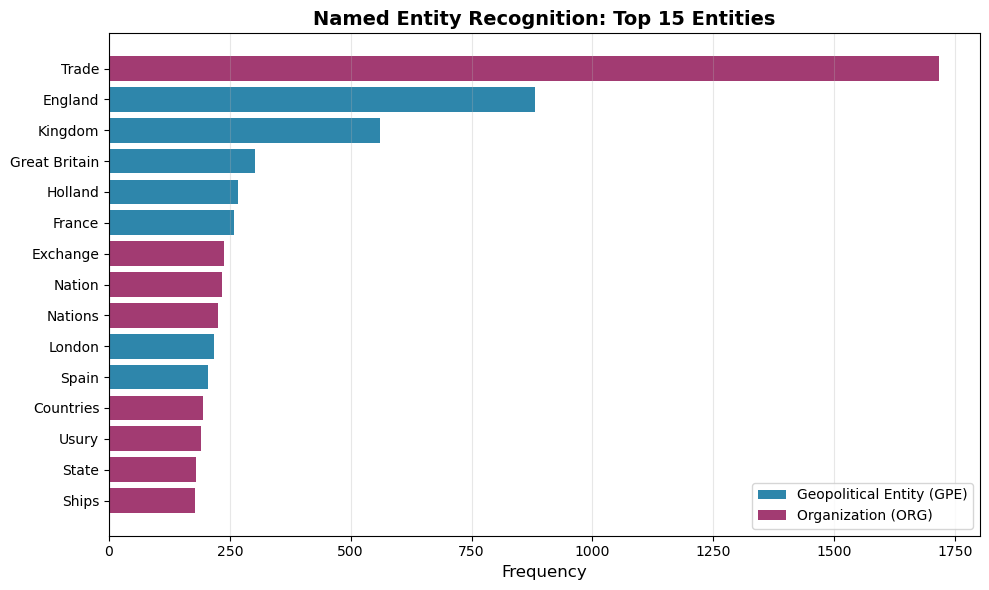

In [29]:
# Visualization of top 15 entities
import matplotlib.pyplot as plt
import seaborn as sns

# Get top 15 entities
top_entities = freq_table.head(15).copy()

# Create the plot
plt.figure(figsize=(10, 6))
colors = {"GPE": "#2E86AB", "ORG": "#A23B72"}
bar_colors = [colors[label] for label in top_entities["label"]]

plt.barh(range(len(top_entities)), top_entities["frequency"], color=bar_colors)
plt.yticks(range(len(top_entities)), top_entities["entity"])
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("")
plt.title("Named Entity Recognition: Top 15 Entities", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()  # Highest frequency at top

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2E86AB", label="Geopolitical Entity (GPE)"),
    Patch(facecolor="#A23B72", label="Organization (ORG)")
]
plt.legend(handles=legend_elements, loc="lower right")

# Clean up grid
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
examples = []

for text in trade_windows:
    doc = nlp(text)
    ents = [ent.text for ent in doc.ents if ent.label_ in ["ORG", "GPE"]]

    if ents:
        examples.append((text, ents))

# print first 5 examples
for text, ents in examples[:5]:
    print("Entities:", ents)
    print(text[:300])
    print("\n---\n")

Entities: ['Trade', 'Riches', 'Holland', 'Land and Interest of Money', 'Universe', 'Territory', 'World', 'Treatise']
it may be 10000 l. and so i● often falls out: Whereas without such an opportunity, he might have laboured all his days for Bread only. So it is in diseases in the Body natural; remove but the cause, take but away the Shackles of Nature, and she will soon recover strength and flesh: so take off the B

---

Entities: ['Soil', 'the Rate of Interest', 'Virginia', 'Laws about Interest of Money', 'Trade', 'Island', 'the City of London', 'Lands', 'Shirts', 'London', 'Barbadoes Planters', 'London', 'Essex', 'Estates', 'Lender', 'Sutton', 'Craven']
and Plantations sell not at above seven years' purchase at most, And, which is more observable, all those Places are not rich or poor according to the goodness of their Soil, but exactly according to the Rate of Interest. Barbadoss the richest Land, hath the poorest People; Virginia the next best La

---

Entities: ['Laws about Interes

In [31]:
freq_table.to_csv("entity_frequency.csv", index=False)

In [32]:
df_entities["entity"] = df_entities["entity"].str.lower()

Q1. Is the concept associated with people, institutions, or places?

The concept of "trade" is primarily associated with places and institutional 
systems rather than specific individuals. We see frequent mentions of locations 
like Holland, Virginia, London, Barbados, and New England—major commercial 
centers of the period. We also encounter institutional references such as 
"Laws about Interest of Money," "Exchange," and "the City of London," 
representing the regulatory and commercial infrastructure governing trade. 
Additionally, references to land, soil, and estates suggest that trade was 
understood in relation to territorial resources and property. 
Overall, "trade" emerges as a spatially and institutionally organized concept 
rather than a person-centered one.

Q2. Do different entities correspond to different uses of the concept?

Yes, different types of entities are linked to different meanings of "trade." 
When trade appears with places (like Holland, Virginia, or Barbados), 
it usually refers to commerce between regions and the movement of goods and 
wealth across territories. When it appears with institutional or legal references 
(like "Laws about Interest of Money" or "Exchange"), it refers more to the 
regulatory frameworks and economic systems that govern commercial activity. 
Additionally, when paired with material entities (like land, soil, or estates), 
trade is discussed in terms of resource extraction and territorial productivity. 
So, the meaning of "trade" shifts depending on context—sometimes it's about 
geographic commerce, sometimes about institutional regulation, and sometimes 
about resource-based economies.

Q3. What are the limitations of NER in your corpus?

There are several problems with using NER on this historical text. 
First, the model sometimes misclassifies common nouns as entities. 
For example, words like "Riches," "Soil," "Lands," "Debt," or "Building" 
are tagged as organizations or locations, even though they are just regular terms. 
Second, the text is written in early modern English, so spelling variations and 
capitalization conventions differ from contemporary usage, making it harder for 
the model to correctly identify entities. Third, some important economic actors 
like merchants, traders, or planters are not consistently detected, even though 
they are central to how trade operated. Finally, NER cannot capture abstract 
concepts like commercial advantage, competitive dynamics, or economic 
interdependence, which are fundamental to understanding "trade" in these texts. 
It only picks up named entities, not the conceptual frameworks that give trade 
its meaning.

### Step 3: BERT

In [57]:
#!pip install sentence-transformers

In [33]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [34]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [35]:
embeddings = model.encode(trade_windows)

In [36]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(embeddings)

df_windows["cluster"] = labels

In [37]:
# cluster distribution

df_windows["cluster"].value_counts()

cluster
1    1151
2     938
0     752
Name: count, dtype: int64

In [38]:
for i in range(k):
    print(f"\nCluster {i}\n")

    cluster_texts = df_windows[df_windows["cluster"] == i]["text"].head(3)

    for text in cluster_texts:
        print("-", text[:200])
        print()


Cluster 0

- it may be 10000 l. and so i● often falls out: Whereas without such an opportunity, he might have laboured all his days for Bread only. So it is in diseases in the Body natural; remove but the cause, t

- New England incomparably is the worst Land of the three, and yet the richest People of them all, and increasing daily to a miracle, unto those that know not that by their Laws about Interest of Money,

- Very angry doubtless he will be; but what then? No question but he will threaten and talk of calling in his Money, but being no Fool but a subtle Person (as hath been said) his prudence will prompt hi


Cluster 1

- and Plantations sell not at above seven years' purchase at most, And, which is more observable, all those Places are not rich or poor according to the goodness of their Soil, but exactly according to 

- because all other Trades that afford a less profit (all hazards considered) are supplied by the Dutch, and must necessarily be so till Interest of Money be ab

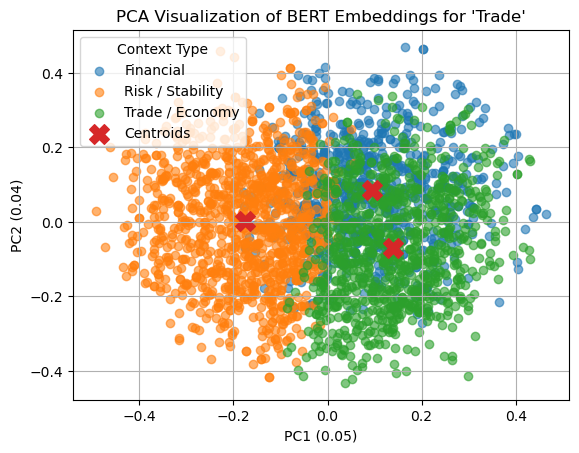

In [39]:
#  Reduce dimensions
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

#  Define cluster names (adjust if needed)
cluster_names = {0: "Financial", 1: "Risk / Stability", 2: "Trade / Economy"}

clusters = np.unique(labels)

#  Plot
plt.figure()

for cluster in clusters:
    idx = labels == cluster
    plt.scatter(
        reduced[idx, 0],
        reduced[idx, 1],
        alpha=0.6,
        label=cluster_names.get(cluster, f"Cluster {cluster}"),
    )

#  Plot cluster centroids
centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], marker="X", s=200, label="Centroids")

# Labels with explained variance
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2f})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2f})")

# Title + legend
plt.title("PCA Visualization of BERT Embeddings for 'Trade'")
plt.legend(title="Context Type")

plt.grid()

plt.show()

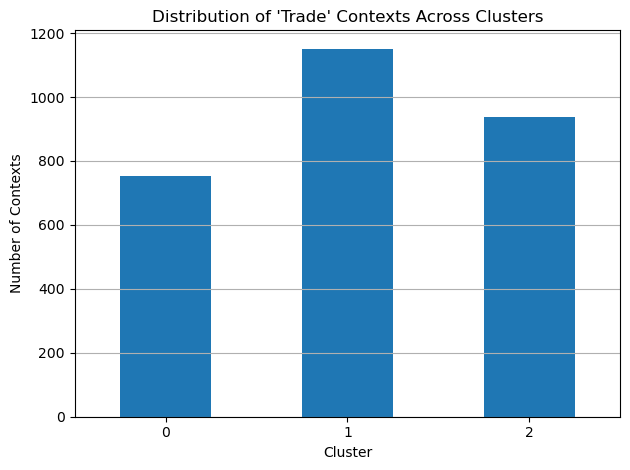

In [40]:
# cluster distribution

cluster_counts = pd.Series(labels).value_counts().sort_index()

plt.figure()
cluster_counts.plot(kind="bar")

plt.title("Distribution of 'Trade' Contexts Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Contexts")

plt.xticks(rotation=0)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [43]:
# Assign labels to clusters based on interpretation
def assign_label(cluster):
    if cluster == 0:
        return "financial"
    elif cluster == 1:
        return "risk_stability"
    elif cluster == 2:
        return "structural"
    else:
        return None

df_windows["label"] = df_windows["cluster"].apply(assign_label)

# Keep only labeled data
df_labeled = df_windows.dropna(subset=["label"])

print(f"Labeled {len(df_labeled)} examples")
print("\nLabel distribution:")
print(df_labeled["label"].value_counts())

Labeled 2841 examples

Label distribution:
label
risk_stability    1151
structural         938
financial          752
Name: count, dtype: int64


In [44]:
# Prepare training data
from sklearn.model_selection import train_test_split

# Get embeddings for labeled data
labeled_indices = df_labeled.index.tolist()
X = embeddings[labeled_indices]
y = df_labeled["label"].values

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 2272
Test samples: 569


In [45]:
# Train classifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Print results
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.98

Classification Report:
                precision    recall  f1-score   support

     financial       1.00      0.95      0.98       151
risk_stability       0.97      1.00      0.98       230
    structural       0.98      0.98      0.98       188

      accuracy                           0.98       569
     macro avg       0.98      0.98      0.98       569
  weighted avg       0.98      0.98      0.98       569



<Figure size 640x480 with 0 Axes>

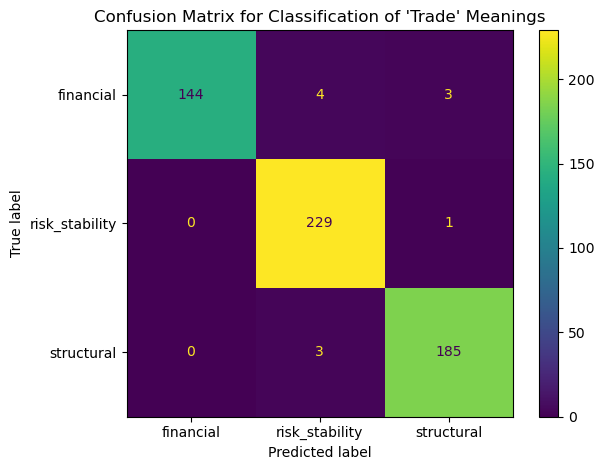

In [46]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)

plt.figure()
disp.plot()

plt.title("Confusion Matrix for Classification of 'Trade' Meanings")
plt.grid(False)

plt.tight_layout()
plt.show()

The BERT embeddings of "trade" contexts were grouped using K-means clustering 
into three clusters. The visualization shows that the contexts form three 
partially overlapping groups, with the orange cluster (Risk/Stability) showing 
the most distinct separation on the left side of the plot, while the blue 
(Financial) and green (Structural) clusters overlap more substantially in the 
center and right portions. This indicates that the model is capturing meaningful 
differences in how "trade" is used across the corpus. While there is some overlap 
between financial and structural uses, the risk-oriented cluster is largely 
separable, suggesting that discussions of trade threats and competition occupy 
a distinct semantic space compared to other commercial discourse.

Q. Do you observe distinct meanings?
Yes, the clustering clearly shows that "trade" appears in distinct groups of 
contexts, meaning it does not have a single fixed meaning. The separation of 
clusters in the visualization suggests that the model is able to capture different 
ways the word is used based on its surrounding text. 

However, the degree of separation varies-the risk/stability cluster forms a 
relatively distinct semantic space, while the financial and structural clusters 
show more overlap, indicating that these uses of "trade" share contextual 
similarities and may blend into one another in practice.

Q. What are the meanings?

> Cluster 0 (Blue) — Financial / Transactional
This cluster represents contexts where "trade" involves merchant decision-making, 
capital deployment, and profit calculations. Examples discuss whether merchants 
should trade with their stock or lend at interest, and how financial laws like 
interest rates affect trading decisions. "Trade" here is an economic activity 
evaluated through financial opportunity costs.

> Cluster 1 (Orange) - Risk / Competitive Threats
This cluster focuses on economic vulnerability and foreign competition, 
particularly Dutch dominance in profitable trades. Examples discuss how high 
interest rates disadvantage English merchants and how different colonies' 
prosperity reflects their economic policies. "Trade" here emphasizes national 
economic struggle and competitive disadvantage.

> Cluster 2 (Green) — Structural / National Prosperity
This cluster encompasses discussions of trade as a driver of national wealth and 
land values. Contexts discuss how expanding trade would increase property prices, 
grow the merchant class, and enhance the kingdom's prosperity. 
"Trade" here is a structural force shaping economic development and social hierarchy.

The differences show that "trade" operates across multiple dimensions: as 
individual financial calculation, as competitive arena, and as engine of 
national prosperity. These meanings are interrelated but emphasize different 
scales of economic activity.

### Step 4: Logistic Regression

In [49]:
def assign_label(cluster):
    if cluster == 0:
        return "financial"
    elif cluster == 1:
        return "risk_stability"
    elif cluster == 2:
        return "structural"
    else:
        return None

df_windows["label"] = df_windows["cluster"].apply(assign_label)

# keep only labeled data
df_labeled = df_windows.dropna(subset=["label"])
df_labeled["label"].value_counts()

label
risk_stability    1151
structural         938
financial          752
Name: count, dtype: int64

In [50]:
df_sample = df_labeled.groupby("label").sample(n=25, random_state=42)

df_sample["label"].value_counts()

label
financial         25
risk_stability    25
structural        25
Name: count, dtype: int64

In [51]:
X = model.encode(df_sample["text"].tolist())
y = df_sample["label"]

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [53]:
# Evaluate performance
from sklearn.metrics import classification_report

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

                precision    recall  f1-score   support

     financial       0.86      1.00      0.92         6
risk_stability       1.00      1.00      1.00         5
    structural       1.00      0.75      0.86         4

      accuracy                           0.93        15
     macro avg       0.95      0.92      0.93        15
  weighted avg       0.94      0.93      0.93        15



In [54]:
X_all = model.encode(df_labeled["text"].tolist())

df_labeled["predicted"] = clf.predict(X_all)

df_labeled.head()

,document,text,cluster,label,predicted
0,A32837.txt,it may be 10000 l. and so i● often falls out: ...,0,financial,structural
1,A32837.txt,and Plantations sell not at above seven years'...,1,risk_stability,risk_stability
2,A32837.txt,New England incomparably is the worst Land of ...,0,financial,risk_stability
3,A32837.txt,Very angry doubtless he will be; but what then...,0,financial,financial
4,A32837.txt,"for his Money, rather than buy Lands at Eighte...",0,financial,financial


Q1. How well does the model distinguish meanings?

The model performs quite well overall, with an accuracy of 93%. 
It correctly identifies most examples across all three categories of "trade." 
In particular, it achieves perfect performance (precision and recall of 1.00) 
for the "risk_stability" cluster, meaning it successfully identifies all 
competitive/threat-oriented contexts without any errors. The "financial" 
category shows perfect recall (1.00), capturing all financial examples, though 
with slightly lower precision (0.86) due to one misclassification. 

The "structural" category demonstrates perfect precision (1.00) but lower 
recall (0.75), indicating the model is accurate when it predicts this category 
but misses some instances. However, the test set is very small (only 15 examples), 
so while the results are promising and suggest the model can distinguish between 
the three meanings, they should be interpreted with caution until validated on a 
larger sample.

Q2. What features seem to drive classification?

The model relies on patterns in the surrounding text captured by the BERT embeddings. 
Contexts that include financial terms—such as money, interest rates, stock, capital, 
or merchant calculations—tend to be classified as financial. 

Contexts that include words related to competition, Dutch rivalry, decay, 
comparative regional analysis, or foreign threats are more likely to be 
classified as risk_stability. Contexts discussing land values, kingdom-wide 
prosperity, national wealth, or the broader economic impact of trade expansion 
tend to be classified as structural. This shows that the model is not just 
looking at the word "trade" itself, but is using the context around it to 
understand its meaning. The perfect performance on the risk_stability cluster 
suggests this category has the most distinctive linguistic markers, while the 
overlap between financial and structural categories indicates they share more 
contextual vocabulary.

Q3. Where does the model fail?

The model makes mistakes in cases where the meaning of "trade" overlaps between 
categories. For example, one "financial" context discussing opportunity and economic 
improvement was predicted as "structural," likely because it included both 
individual merchant decision-making and broader systemic economic benefits. 
Another "financial" example about New England's laws and interest rates was 
misclassified as "risk_stability," probably because it combined financial 
mechanisms with regional competitive dynamics. One "structural" instance was 
predicted as "financial," reflecting contexts where national prosperity 
discussions merge with capital deployment language. This reflects a key 
challenge in the concept itself: in early modern texts, individual merchant 
behavior, competitive threats, and national economic structure are often 
closely connected rather than completely separate. Additionally, the very 
small test set (15 examples) limits the model's ability to demonstrate robust 
generalization, and some errors may stem from imperfect labeling based on 
clustering. These issues highlight that while the model works well, it does not 
fully capture the complexity and multidimensional nature of "trade" as a concept.

Overall, the results suggest that while the meanings of "trade" are 
distinguishable, they are also partially overlapping, reflecting the concept's 
multidimensional nature. Financial calculations, competitive risks, 
and structural economic forces were understood as interconnected aspects of 
commerce in early modern thought rather than as entirely separate phenomena.

Step 5: Synthesis - Refer report

Central Claim: 

The concept of "trade" in this corpus is not a single fixed idea, but a 
multi-dimensional concept structured across three 
interconnected meanings: financial/transactional, competitive/risk-oriented, 
and structural/prosperity-driven. These meanings are not separate, but overlap 
and reinforce each other, reflecting how early modern economic thought 
understood commerce simultaneously as individual merchant decision-making, 
as a site of international rivalry and vulnerability, and as the engine of 
national wealth and social advancement.